In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from textblob import TextBlob

In [7]:
import os

os.chdir(r"C:\Users\DELL\Desktop\task 8")
print(os.getcwd())

C:\Users\DELL\Desktop\task 8


In [2]:
os.listdir()

['googleplaystore.csv', 'googleplaystore_user_reviews.csv']

In [8]:
apps = pd.read_csv("googleplaystore.csv")
apps.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [9]:
reviews = pd.read_csv("googleplaystore_user_reviews.csv")

reviews.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [10]:
print("Apps dataset shape:", apps.shape)
print("Reviews dataset shape:", reviews.shape)

Apps dataset shape: (10841, 13)
Reviews dataset shape: (64295, 5)


In [11]:
print("Apps columns:")
print(apps.columns.tolist())

print("\nReviews columns:")
print(reviews.columns.tolist())

Apps columns:
['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']

Reviews columns:
['App', 'Translated_Review', 'Sentiment', 'Sentiment_Polarity', 'Sentiment_Subjectivity']


In [12]:
apps.info()

<class 'pandas.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  str    
 1   Category        10841 non-null  str    
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  str    
 4   Size            10841 non-null  str    
 5   Installs        10841 non-null  str    
 6   Type            10840 non-null  str    
 7   Price           10841 non-null  str    
 8   Content Rating  10840 non-null  str    
 9   Genres          10841 non-null  str    
 10  Last Updated    10841 non-null  str    
 11  Current Ver     10833 non-null  str    
 12  Android Ver     10838 non-null  str    
dtypes: float64(1), str(12)
memory usage: 1.1 MB


In [13]:
apps.isnull().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

In [14]:
apps.duplicated().sum()

np.int64(483)

In [15]:
reviews.info()

<class 'pandas.DataFrame'>
RangeIndex: 64295 entries, 0 to 64294
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     64295 non-null  str    
 1   Translated_Review       37427 non-null  str    
 2   Sentiment               37432 non-null  str    
 3   Sentiment_Polarity      37432 non-null  float64
 4   Sentiment_Subjectivity  37432 non-null  float64
dtypes: float64(2), str(3)
memory usage: 2.5 MB


In [16]:
reviews.isnull().sum()

App                           0
Translated_Review         26868
Sentiment                 26863
Sentiment_Polarity        26863
Sentiment_Subjectivity    26863
dtype: int64

In [17]:
reviews.duplicated().sum()

np.int64(33616)

In [18]:
apps.describe()

,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


In [20]:
apps.duplicated().sum()

np.int64(483)

In [21]:
apps = apps.drop_duplicates()

In [22]:
apps.shape

(10358, 13)

In [23]:
apps['Installs'] = apps['Installs'].str.replace(',', '', regex=False).str.replace('+', '', regex=False)
apps['Installs'] = pd.to_numeric(apps['Installs'], errors='coerce')

In [24]:
apps['Installs'].head()


0       10000.0
1      500000.0
2     5000000.0
3    50000000.0
4      100000.0
Name: Installs, dtype: float64

In [25]:
apps['Price'] = apps['Price'].str.replace('$', '', regex=False)
apps['Price'] = pd.to_numeric(apps['Price'], errors='coerce')

In [26]:
apps['Price'].head()

0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: Price, dtype: float64

In [28]:
import numpy as np

In [29]:
def convert_size(size):
    if size == 'Varies with device':
        return np.nan
    elif isinstance(size, str):
        if 'M' in size:
            return float(size.replace('M', ''))
        elif 'k' in size:
            return float(size.replace('k', '')) / 1024
    return np.nan

apps['Size'] = apps['Size'].apply(convert_size)

In [30]:
apps['Size'].head(10)

0    19.0
1    14.0
2     8.7
3    25.0
4     2.8
5     5.6
6    19.0
7    29.0
8    33.0
9     3.1
Name: Size, dtype: float64

In [31]:
apps.isnull().sum()

App                  0
Category             0
Rating            1465
Reviews              0
Size              1527
Installs             1
Type                 1
Price                1
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

In [32]:
apps = apps.dropna(subset=['Rating'])

In [33]:
apps.isnull().sum()

App                  0
Category             0
Rating               0
Reviews              0
Size              1469
Installs             1
Type                 0
Price                1
Content Rating       1
Genres               0
Last Updated         0
Current Ver          4
Android Ver          3
dtype: int64

In [34]:
apps.dtypes

App                   str
Category              str
Rating            float64
Reviews               str
Size              float64
Installs          float64
Type                  str
Price             float64
Content Rating        str
Genres                str
Last Updated          str
Current Ver           str
Android Ver           str
dtype: object

In [35]:
apps.info()


<class 'pandas.DataFrame'>
Index: 8893 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             8893 non-null   str    
 1   Category        8893 non-null   str    
 2   Rating          8893 non-null   float64
 3   Reviews         8893 non-null   str    
 4   Size            7424 non-null   float64
 5   Installs        8892 non-null   float64
 6   Type            8893 non-null   str    
 7   Price           8892 non-null   float64
 8   Content Rating  8892 non-null   str    
 9   Genres          8893 non-null   str    
 10  Last Updated    8893 non-null   str    
 11  Current Ver     8889 non-null   str    
 12  Android Ver     8890 non-null   str    
dtypes: float64(4), str(9)
memory usage: 972.7 KB


In [36]:
apps.shape

(8893, 13)

In [37]:
category_counts = apps['Category'].value_counts()

category_counts

Category
FAMILY                 1718
GAME                   1074
TOOLS                   734
PRODUCTIVITY            334
FINANCE                 317
PERSONALIZATION         310
COMMUNICATION           307
LIFESTYLE               305
PHOTOGRAPHY             304
MEDICAL                 302
SPORTS                  286
BUSINESS                270
HEALTH_AND_FITNESS      262
SOCIAL                  244
NEWS_AND_MAGAZINES      214
TRAVEL_AND_LOCAL        205
SHOPPING                202
BOOKS_AND_REFERENCE     177
VIDEO_PLAYERS           160
DATING                  159
EDUCATION               129
MAPS_AND_NAVIGATION     124
ENTERTAINMENT           111
FOOD_AND_DRINK          106
WEATHER                  75
AUTO_AND_VEHICLES        73
HOUSE_AND_HOME           68
LIBRARIES_AND_DEMO       65
ART_AND_DESIGN           62
COMICS                   58
PARENTING                50
EVENTS                   45
BEAUTY                   42
1.9                       1
Name: count, dtype: int64

In [39]:
import matplotlib.pyplot as plt

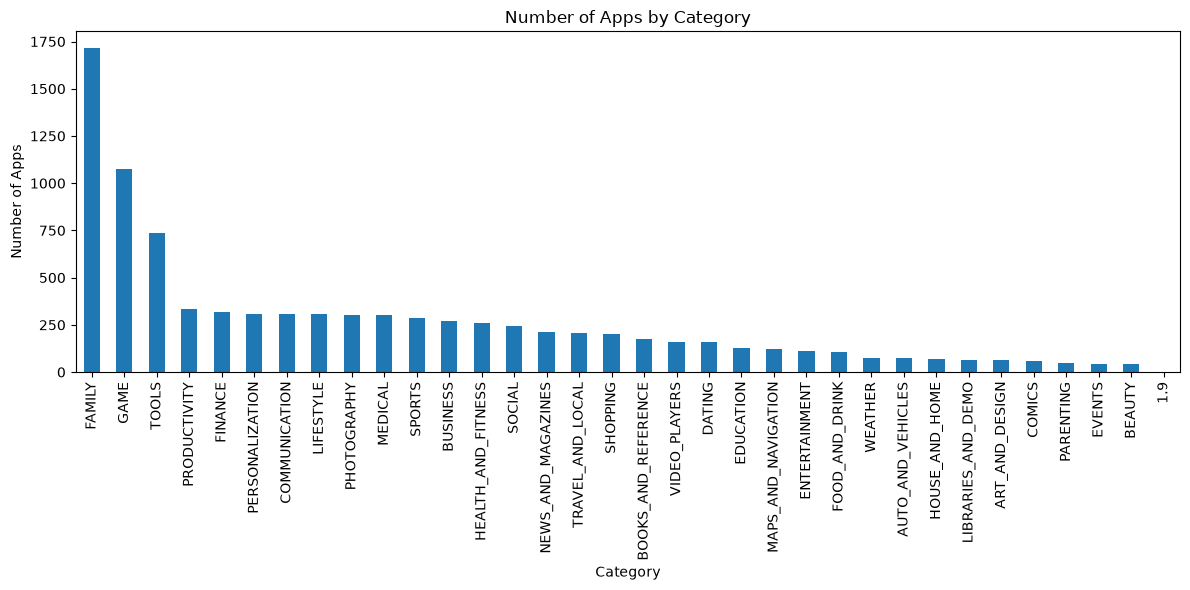

In [40]:
plt.figure(figsize=(12, 6))

category_counts.plot(kind='bar')

plt.title('Number of Apps by Category')
plt.xlabel('Category')
plt.ylabel('Number of Apps')
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [41]:
category_counts.head(10)

Category
FAMILY             1718
GAME               1074
TOOLS               734
PRODUCTIVITY        334
FINANCE             317
PERSONALIZATION     310
COMMUNICATION       307
LIFESTYLE           305
PHOTOGRAPHY         304
MEDICAL             302
Name: count, dtype: int64

In [14]:
apps_clean = apps.dropna(subset=['Rating']).copy()

print("Apps with ratings:", len(apps_clean))

Apps with ratings: 8893


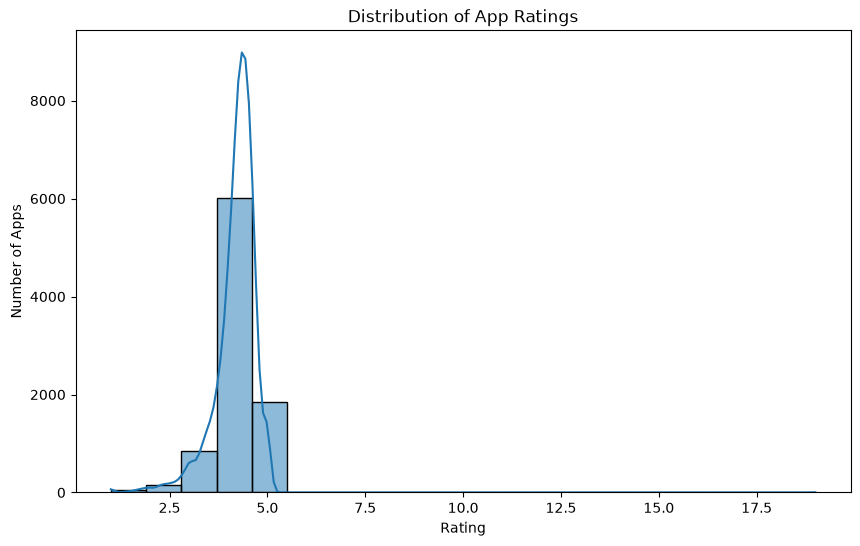

In [15]:
plt.figure(figsize=(10, 6))

sns.histplot(apps_clean['Rating'], bins=20, kde=True)

plt.title('Distribution of App Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Apps')

plt.show()

In [16]:
avg_rating_category = apps_clean.groupby('Category')['Rating'].mean().sort_values(ascending=False)

avg_rating_category

Category
1.9                    19.000000
EVENTS                  4.435556
EDUCATION               4.375969
ART_AND_DESIGN          4.358065
BOOKS_AND_REFERENCE     4.347458
PERSONALIZATION         4.333871
PARENTING               4.300000
GAME                    4.281285
BEAUTY                  4.278571
HEALTH_AND_FITNESS      4.261450
SOCIAL                  4.254918
SHOPPING                4.251485
WEATHER                 4.244000
SPORTS                  4.225175
PRODUCTIVITY            4.201796
FAMILY                  4.191153
AUTO_AND_VEHICLES       4.190411
PHOTOGRAPHY             4.182895
MEDICAL                 4.182450
LIBRARIES_AND_DEMO      4.178462
HOUSE_AND_HOME          4.164706
FOOD_AND_DRINK          4.164151
COMICS                  4.155172
COMMUNICATION           4.151466
ENTERTAINMENT           4.136036
NEWS_AND_MAGAZINES      4.128505
FINANCE                 4.127445
BUSINESS                4.102593
LIFESTYLE               4.096066
TRAVEL_AND_LOCAL        4.094146
V

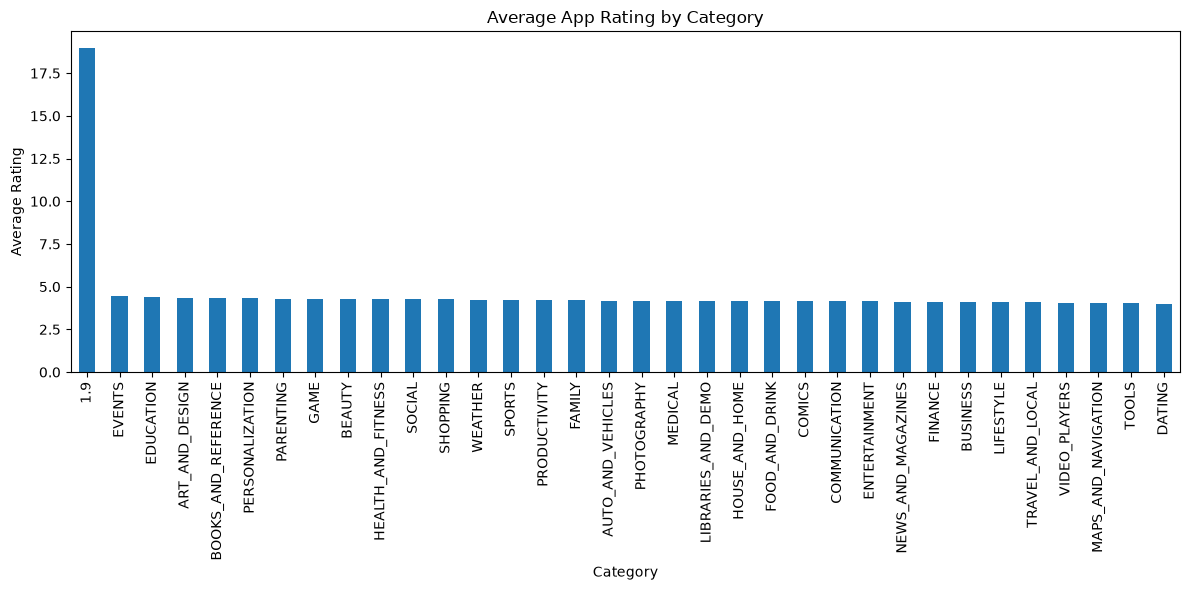

In [17]:
plt.figure(figsize=(12, 6))

avg_rating_category.plot(kind='bar')

plt.title('Average App Rating by Category')
plt.xlabel('Category')
plt.ylabel('Average Rating')
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [18]:
size_installs = apps.dropna(subset=['Size', 'Installs']).copy()

print("Rows available for analysis:", len(size_installs))

Rows available for analysis: 8831


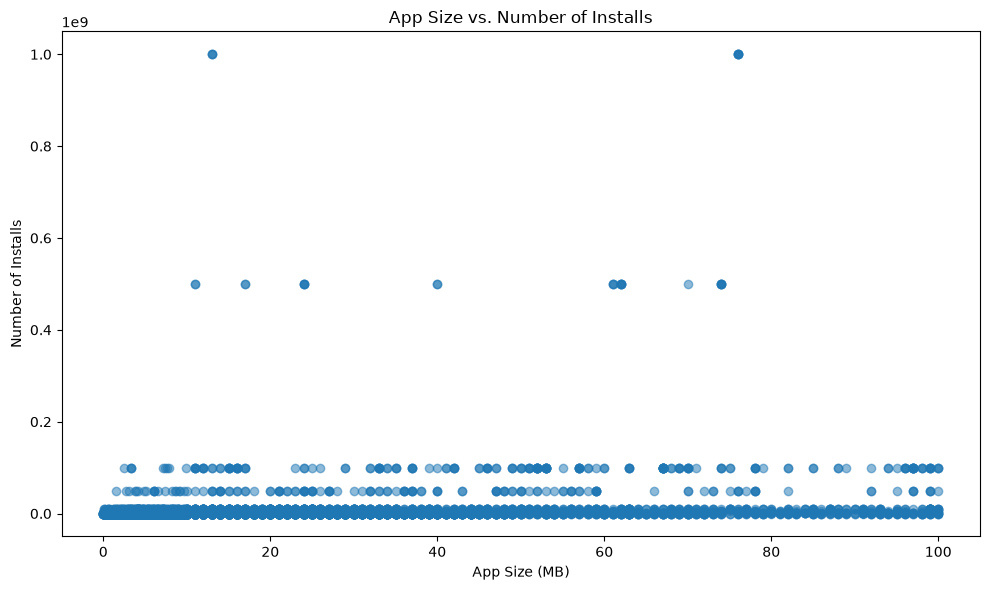

In [19]:
plt.figure(figsize=(10, 6))

plt.scatter(size_installs['Size'], size_installs['Installs'], alpha=0.5)

plt.title('App Size vs. Number of Installs')
plt.xlabel('App Size (MB)')
plt.ylabel('Number of Installs')

plt.tight_layout()
plt.show()

In [20]:
correlation = size_installs['Size'].corr(size_installs['Installs'])

print("Correlation between App Size and Installs:", correlation)

Correlation between App Size and Installs: 0.16887201973119784


In [21]:
type_counts = apps['Type'].value_counts()

print(type_counts)

Type
Free    9591
Paid     765
0          1
Name: count, dtype: int64


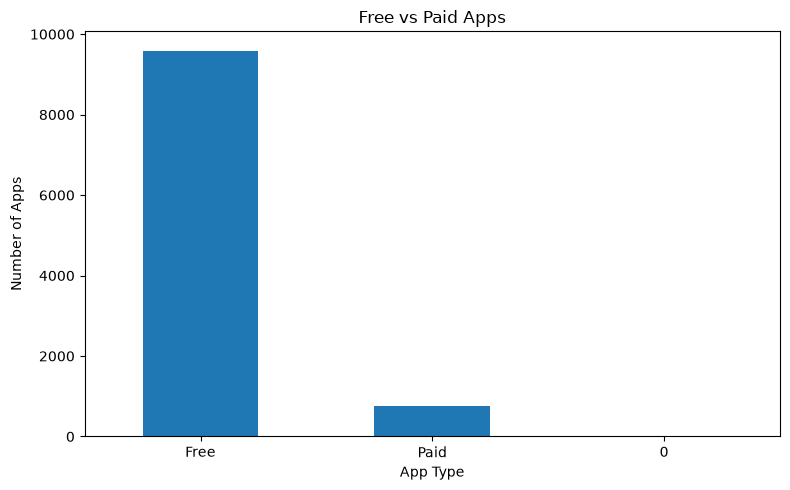

In [22]:
plt.figure(figsize=(8, 5))

type_counts.plot(kind='bar')

plt.title('Free vs Paid Apps')
plt.xlabel('App Type')
plt.ylabel('Number of Apps')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [23]:
paid_apps = apps[apps['Type'] == 'Paid'].copy()

print("Number of paid apps:", len(paid_apps))

Number of paid apps: 765


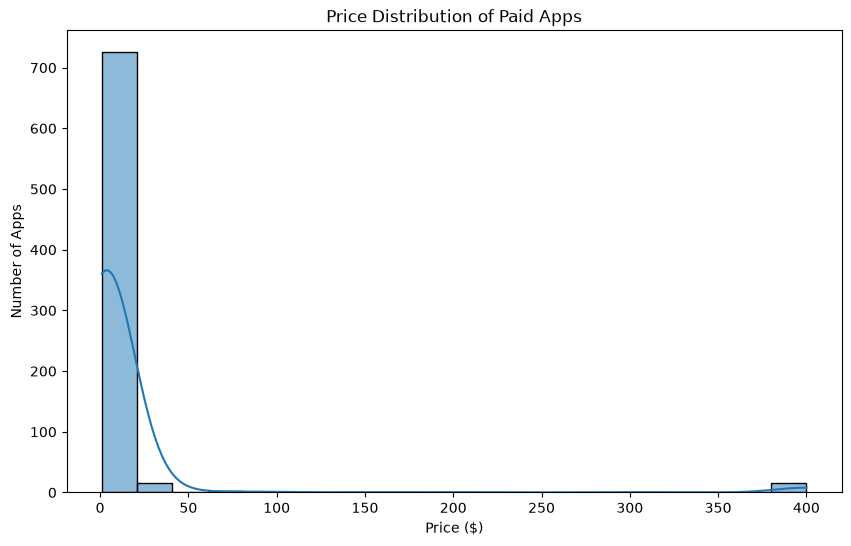

In [24]:
plt.figure(figsize=(10, 6))

sns.histplot(paid_apps['Price'], bins=20, kde=True)

plt.title('Price Distribution of Paid Apps')
plt.xlabel('Price ($)')
plt.ylabel('Number of Apps')

plt.show()

In [25]:
paid_apps['Estimated_Revenue'] = paid_apps['Installs'] * paid_apps['Price']

revenue_by_category = (
    paid_apps.groupby('Category')['Estimated_Revenue']
    .sum()
    .sort_values(ascending=False)
)

revenue_by_category

Category
FAMILY                 1.857803e+08
LIFESTYLE              5.758394e+07
GAME                   4.098764e+07
FINANCE                2.572668e+07
PHOTOGRAPHY            8.942768e+06
MEDICAL                8.456536e+06
PERSONALIZATION        7.786948e+06
TOOLS                  5.464821e+06
SPORTS                 4.706212e+06
PRODUCTIVITY           4.313375e+06
COMMUNICATION          4.247364e+06
WEATHER                4.181380e+06
EDUCATION              2.403980e+06
HEALTH_AND_FITNESS     1.426069e+06
MAPS_AND_NAVIGATION    1.240789e+06
TRAVEL_AND_LOCAL       1.151504e+06
BUSINESS               1.050543e+06
ENTERTAINMENT          7.980000e+05
VIDEO_PLAYERS          3.352900e+05
FOOD_AND_DRINK         2.844000e+05
PARENTING              2.499590e+05
AUTO_AND_VEHICLES      1.001485e+05
BOOKS_AND_REFERENCE    9.022674e+04
DATING                 8.836150e+04
ART_AND_DESIGN         3.184000e+04
SHOPPING               3.014900e+04
NEWS_AND_MAGAZINES     6.445000e+03
SOCIAL             

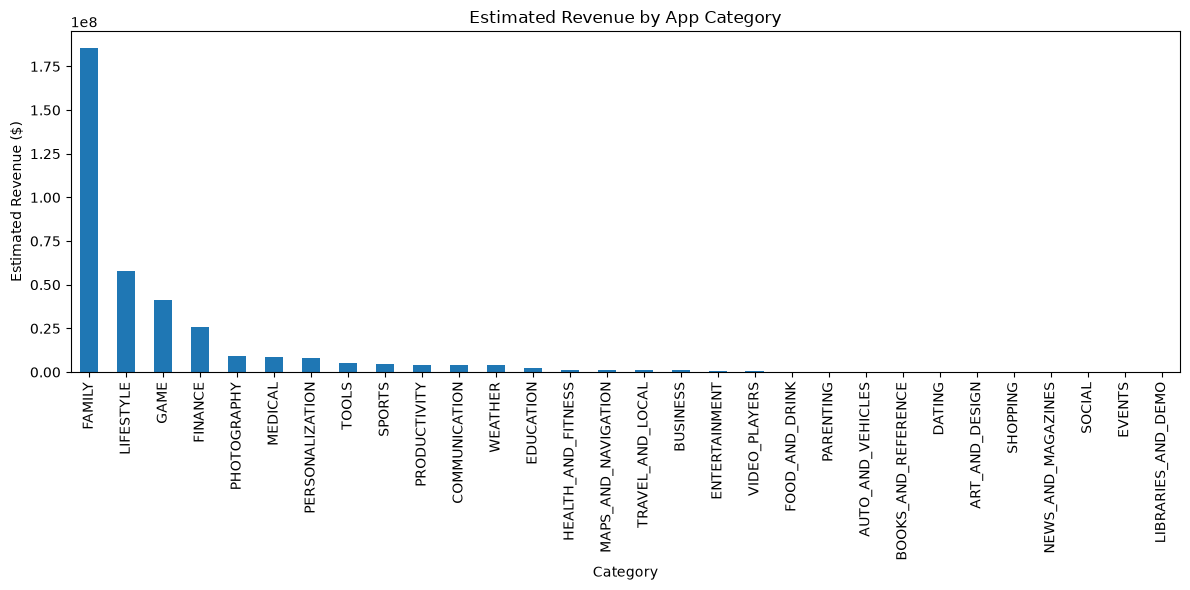

In [26]:
plt.figure(figsize=(12, 6))

revenue_by_category.plot(kind='bar')

plt.title('Estimated Revenue by App Category')
plt.xlabel('Category')
plt.ylabel('Estimated Revenue ($)')
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [31]:
reviews['Sentiment'].value_counts()

Sentiment
Positive    23998
Negative     8271
Neutral      5163
Name: count, dtype: int64

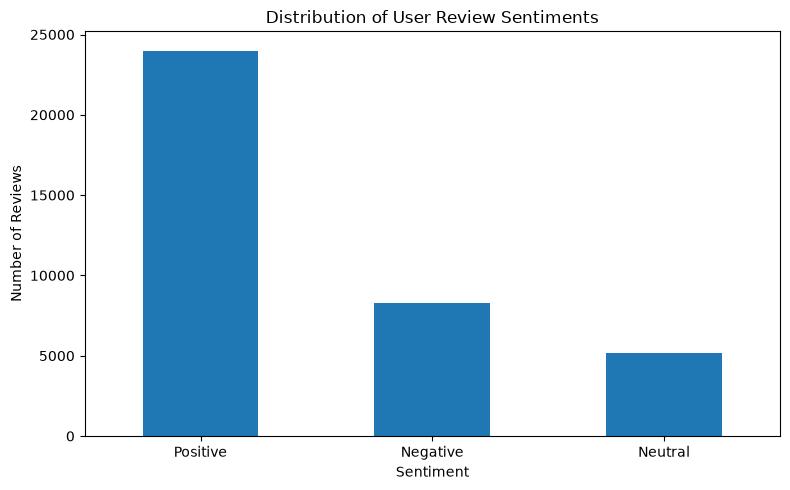

In [32]:
sentiment_counts = reviews['Sentiment'].value_counts()

plt.figure(figsize=(8, 5))

sentiment_counts.plot(kind='bar')

plt.title('Distribution of User Review Sentiments')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [33]:
reviews_category = reviews.merge(
    apps[['App', 'Category']],
    on='App',
    how='left'
)

print(reviews_category[['App', 'Category', 'Sentiment']].head())

                     App            Category Sentiment
0  10 Best Foods for You  HEALTH_AND_FITNESS  Positive
1  10 Best Foods for You  HEALTH_AND_FITNESS  Positive
2  10 Best Foods for You  HEALTH_AND_FITNESS       NaN
3  10 Best Foods for You  HEALTH_AND_FITNESS  Positive
4  10 Best Foods for You  HEALTH_AND_FITNESS  Positive


In [34]:
sentiment_by_category = pd.crosstab(
    reviews_category['Category'],
    reviews_category['Sentiment'],
    normalize='index'
) * 100

sentiment_by_category = sentiment_by_category.sort_values(
    by='Positive',
    ascending=False
)

sentiment_by_category.head(10)

Sentiment,Negative,Neutral,Positive
Category,,,
COMICS,2.439024,9.756098,87.804878
AUTO_AND_VEHICLES,5.882353,12.456747,81.660900
EVENTS,10.126582,10.759494,79.113924
EDUCATION,12.302285,9.402460,78.295255
HEALTH_AND_FITNESS,12.942827,10.873378,76.183795
FOOD_AND_DRINK,13.528591,12.412831,74.058577
LIBRARIES_AND_DEMO,15.315315,13.213213,71.471471
PARENTING,8.846154,20.000000,71.153846
WEATHER,14.163090,15.021459,70.815451


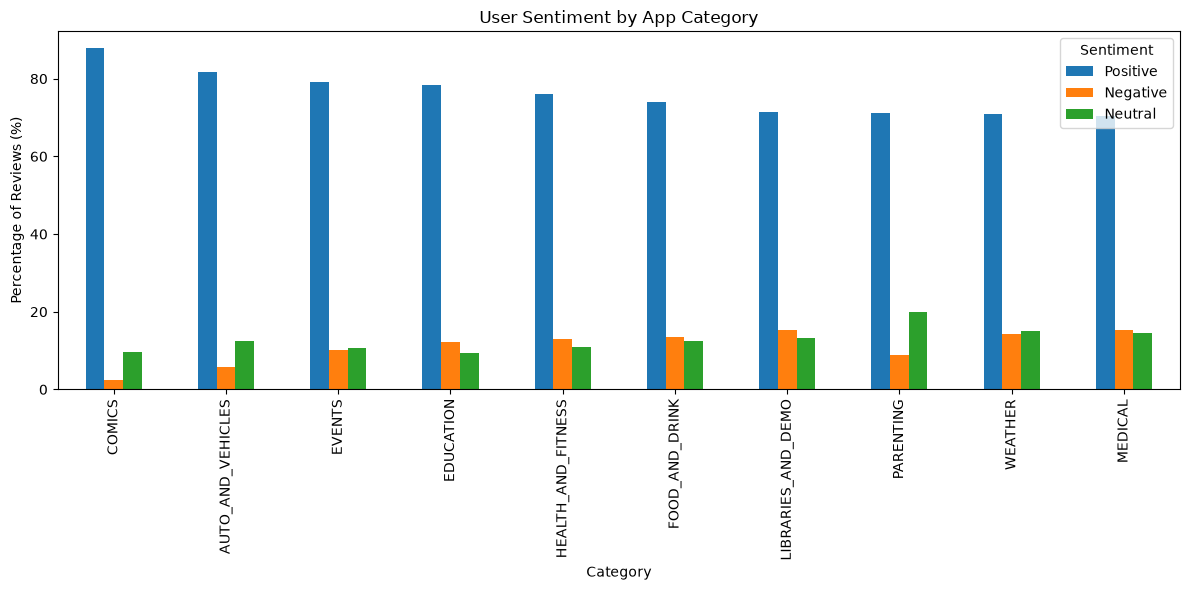

In [35]:
sentiment_by_category[['Positive', 'Negative', 'Neutral']].head(10).plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('User Sentiment by App Category')
plt.xlabel('Category')
plt.ylabel('Percentage of Reviews (%)')
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [1]:
%pip install plotly

   ---------------------------------------- 0.0/9.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.1 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.1 MB 1.6 MB/s eta 0:00:06
   ----- ---------------------------------- 1.3/9.1 MB 1.9 MB/s eta 0:00:05
   --------- ------------------------------ 2.1/9.1 MB 2.4 MB/s eta 0:00:03
   ------------ --------------------------- 2.9/9.1 MB 2.6 MB/s eta 0:00:03
   ---------------- ----------------------- 3.7/9.1 MB 2.8 MB/s eta 0:00:02
   ------------------ --------------------- 4.2/9.1 MB 2.8 MB/s eta 0:00:02
   ---------------------- ----------------- 5.0/9.1 MB 2.9 MB/s eta 0:00:02
   -------------------------- ------------- 6.0/9.1 MB 3.2 MB/s eta 0:00:01
   ------------------------------ --------- 6.8

In [2]:
import plotly.express as px

print("Plotly is working!")

Plotly is working!


In [6]:
import pandas as pd
import plotly.express as px
import os

os.chdir(r"C:\Users\DELL\Desktop\task 8")

apps = pd.read_csv("googleplaystore.csv")

category_counts = apps['Category'].value_counts()

fig = px.bar(
    x=category_counts.index,
    y=category_counts.values,
    labels={
        'x': 'Category',
        'y': 'Number of Apps'
    },
    title='Interactive App Distribution by Category'
)

fig.show()

In [2]:
import pandas as pd
import numpy as np
import os

# Set folder
os.chdir(r"C:\Users\DELL\Desktop\task 8")

# Load datasets
apps = pd.read_csv("googleplaystore.csv")
reviews = pd.read_csv("googleplaystore_user_reviews.csv")

# Remove duplicates
apps = apps.drop_duplicates()

# Clean Installs
apps['Installs'] = apps['Installs'].str.replace(',', '', regex=False)
apps['Installs'] = apps['Installs'].str.replace('+', '', regex=False)
apps['Installs'] = pd.to_numeric(apps['Installs'], errors='coerce')

# Clean Price
apps['Price'] = apps['Price'].str.replace('$', '', regex=False)
apps['Price'] = pd.to_numeric(apps['Price'], errors='coerce')

# Clean Size
def convert_size(size):
    if pd.isna(size) or size == 'Varies with device':
        return np.nan
    if isinstance(size, str):
        if 'M' in size:
            return float(size.replace('M', ''))
        elif 'k' in size:
            return float(size.replace('k', '')) / 1024
    return np.nan

apps['Size'] = apps['Size'].apply(convert_size)

# Data needed for analysis
apps_clean = apps.dropna(subset=['Rating']).copy()
size_installs = apps.dropna(subset=['Size', 'Installs']).copy()

# Final results
print("TOP 5 CATEGORIES")
print(apps['Category'].value_counts().head())

print("\nAVERAGE RATING")
print(apps_clean['Rating'].mean())

print("\nFREE VS PAID")
print(apps['Type'].value_counts())

print("\nSIZE VS INSTALLS CORRELATION")
print(size_installs['Size'].corr(size_installs['Installs']))

print("\nSENTIMENT")
print(reviews['Sentiment'].value_counts())

TOP 5 CATEGORIES
Category
FAMILY      1943
GAME        1121
TOOLS        843
BUSINESS     427
MEDICAL      408
Name: count, dtype: int64

AVERAGE RATING
4.18954233666929

FREE VS PAID
Type
Free    9591
Paid     765
0          1
Name: count, dtype: int64

SIZE VS INSTALLS CORRELATION
0.16887201973119784

SENTIMENT
Sentiment
Positive    23998
Negative     8271
Neutral      5163
Name: count, dtype: int64


## Conclusion

The Google Play Store analysis shows that the market is highly competitive, particularly in categories such as Family, Games, and Tools. The Family category has the highest number of apps, with 1,943 applications. The average app rating is approximately 4.19, showing generally positive ratings across the marketplace.

The analysis also found a weak positive correlation of 0.169 between app size and installs, indicating that app size has little relationship with download numbers. In addition, free apps greatly outnumber paid apps, with 9,591 free apps compared with 765 paid apps.

User sentiment was predominantly positive, with 23,998 positive reviews, compared with 8,271 negative and 5,163 neutral reviews.

For a developer planning to launch a new app, the findings suggest focusing on a less saturated category, prioritizing a high-quality user experience rather than simply increasing app size, and considering a free or freemium approach to attract more users.
